# CivicConnect AI – Smart Public Grievance & Resolution Platform

This notebook trains an AI model to classify citizen complaints into civic categories.
The workflow uses complaint text, TF-IDF features, and an Artificial Neural Network (ANN).

## 1. Import Required Libraries

These libraries are used for data handling, visualization, text processing, ANN training, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping


## 2. Load CivicConnect Dataset

The dataset contains citizen complaint text and the corresponding civic complaint category.

In [2]:
df = pd.read_csv(
    r"C:\Users\vaish\OneDrive\Desktop\CivicConnectAI\dataset\civic_complaints.csv"
)

print("Dataset loaded successfully! ✅")
print("Shape:", df.shape)


Dataset loaded successfully! ✅
Shape: (1200, 2)


## 3. View First Records

This shows sample citizen complaints and their assigned civic categories.

In [3]:
df.head()

,complaint_text,category
0,Our locality has an overflowing garbage bin,Garbage
1,Electricity is unavailable in the area,Electricity
2,Drain water is entering the road,Drainage
3,Waste has been dumped on the roadside,Garbage
4,There is a problem with the power line,Electricity


## 4. View Last Records

This displays the last few complaints in the CivicConnect dataset.

In [4]:
df.tail()

,complaint_text,category
1195,The drainage is overflowing near our houses,Drainage
1196,There is stagnant water because of blocked dra...,Drainage
1197,The drainage system needs immediate repair,Drainage
1198,The road surface is broken near the bus stop,Road Damage
1199,There is very low water pressure,Water Supply


## 5. Dataset Shape

The shape shows the number of complaint records and columns.

In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 1200
Columns: 2


## 6. Dataset Size

This gives the total number of values present in the dataset.

In [6]:
print("Total values:", df.size)

Total values: 2400


## 7. Dataset Columns

The important CivicConnect columns are `complaint_text` and `category`.

In [7]:
print(df.columns.tolist())

['complaint_text', 'category']


## 8. Dataset Information

This displays data types and non-null values for every column.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   complaint_text  1200 non-null   object
 1   category        1200 non-null   object
dtypes: object(2)
memory usage: 18.9+ KB


## 9. Statistical Summary

Numeric columns, if available, are summarized here.

In [9]:
df.describe(include="all").T

,count,unique,top,freq
complaint_text,1200,80,Our locality has an overflowing garbage bin,15
category,1200,8,Garbage,150


## 10. Missing Values

We check whether any complaint or category values are missing.

In [10]:
print(df.isnull().sum())

complaint_text    0
category          0
dtype: int64


## 11. Duplicate Complaints

Duplicate rows are checked before model training.

In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1120


## 12. Data Types

This confirms the type of each CivicConnect dataset column.

In [12]:
print(df.dtypes)

complaint_text    object
category          object
dtype: object


## 13. Civic Complaint Categories

This displays all categories available for AI classification.

In [13]:
print(df["category"].unique())
print("Number of categories:", df["category"].nunique())

['Garbage' 'Electricity' 'Drainage' 'Road Damage' 'Sanitation' 'Other'
 'Street Light' 'Water Supply']
Number of categories: 8


## 14. Category Distribution

The number of complaints in each civic category is displayed.

In [14]:
print(df["category"].value_counts())

category
Garbage         150
Electricity     150
Drainage        150
Road Damage     150
Sanitation      150
Other           150
Street Light    150
Water Supply    150
Name: count, dtype: int64


## 15. Category Distribution Plot

This visualization shows how complaints are distributed across civic categories.

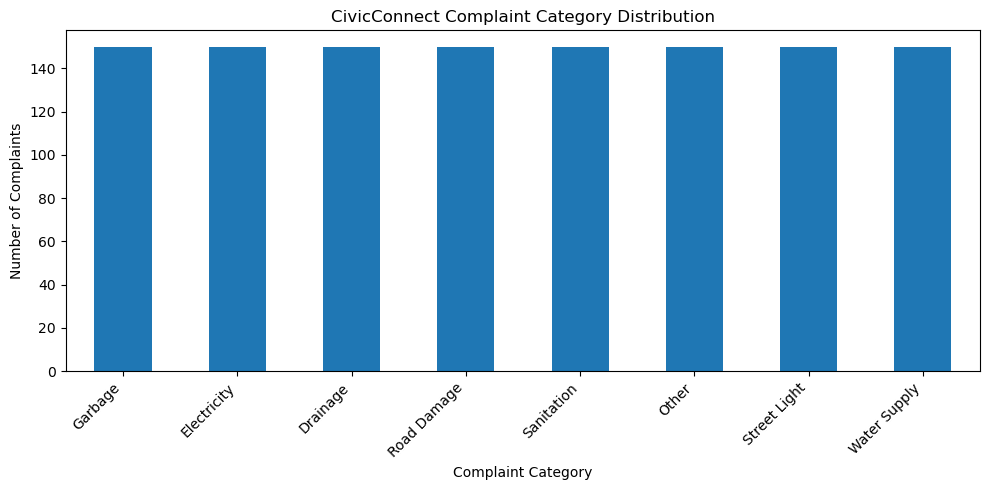

In [15]:
plt.figure(figsize=(10, 5))
df["category"].value_counts().plot(kind="bar")
plt.title("CivicConnect Complaint Category Distribution")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 16. Complaint Text Length

Complaint length is calculated to understand the text data.

In [16]:
df["text_length"] = df["complaint_text"].astype(str).str.len()
print(df["text_length"].describe())

count    1200.000000
mean       37.950000
std         5.284011
min        27.000000
25%        34.750000
50%        38.000000
75%        41.250000
max        51.000000
Name: text_length, dtype: float64


## 17. Complaint Text Length Plot

The distribution helps us understand the size of citizen complaint descriptions.

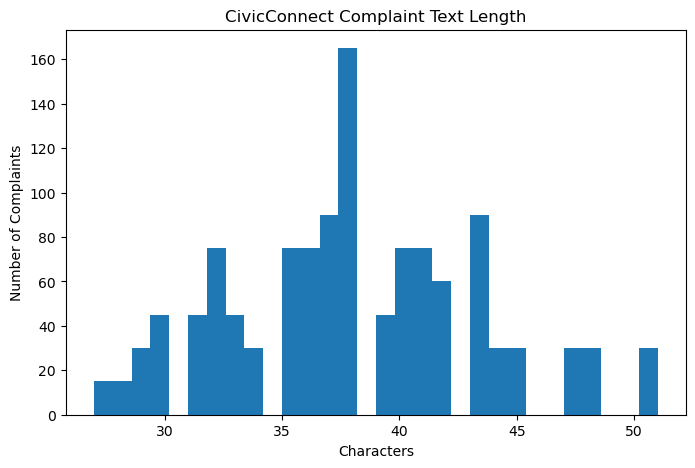

In [17]:
plt.figure(figsize=(8, 5))
plt.hist(df["text_length"], bins=30)
plt.title("CivicConnect Complaint Text Length")
plt.xlabel("Characters")
plt.ylabel("Number of Complaints")
plt.show()

## 18. Prepare Features and Target

`complaint_text` is the input feature and `category` is the target label.

In [18]:
X = df["complaint_text"].astype(str)
y = df["category"].astype(str)

print("Input samples:", X.shape)
print("Target samples:", y.shape)

Input samples: (1200,)
Target samples: (1200,)


## 19. Train-Test Split

80% of complaints are used for training and 20% for testing.
Stratification keeps the category distribution balanced.

In [19]:
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train_text.shape)
print("Testing samples:", X_test_text.shape)

Training samples: (960,)
Testing samples: (240,)


## 20. Convert Complaint Text to TF-IDF

TF-IDF converts citizen complaint text into numerical features that the ANN can learn from.

In [20]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    max_features=5000
)

X_train = tfidf.fit_transform(X_train_text).toarray()
X_test = tfidf.transform(X_test_text).toarray()

print("Training TF-IDF shape:", X_train.shape)
print("Testing TF-IDF shape:", X_test.shape)

Training TF-IDF shape: (960, 319)
Testing TF-IDF shape: (240, 319)


## 21. Encode Complaint Categories

The eight civic categories are converted into numeric labels for ANN training.

In [21]:
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)

print("Classes:")
for i, name in enumerate(label_encoder.classes_):
    print(i, "->", name)

Classes:
0 -> Drainage
1 -> Electricity
2 -> Garbage
3 -> Other
4 -> Road Damage
5 -> Sanitation
6 -> Street Light
7 -> Water Supply


## 22. Build CivicConnect ANN

The ANN uses TF-IDF complaint features and predicts one of the CivicConnect complaint categories.

In [22]:
num_features = X_train.shape[1]
num_classes = len(label_encoder.classes_)

ann = Sequential([
    Input(shape=(num_features,)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(num_classes, activation="softmax")
])

ann.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        40,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,560 (201.41 KB)

 Trainable params: 51,560 (201.41 KB)

 Non-trainable params: 0 (0.00 B)

## 23. Compile ANN

Sparse categorical cross-entropy is used because this is a multi-class complaint classification problem.

In [23]:
ann.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("ANN compiled successfully! ✅")

ANN compiled successfully! ✅


## 24. Early Stopping

Training stops when validation loss does not improve for several epochs, helping reduce overfitting.

In [24]:
es = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

## 25. Train CivicConnect ANN

The model learns patterns from citizen complaints and validates them on unseen test complaints.

In [25]:
history = ann.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[es],
    verbose=1
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4490 - loss: 1.9886 - val_accuracy: 0.6000 - val_loss: 1.8382
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7469 - loss: 1.4697 - val_accuracy: 0.9458 - val_loss: 0.9394
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9917 - loss: 0.4371 - val_accuracy: 1.0000 - val_loss: 0.0991
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0385 - val_accuracy: 1.0000 - val_loss: 0.0155
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0101 - val_accuracy: 1.0000 - val_loss: 0.0074
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0056 - val_accuracy: 1.0000 - val_loss: 0.0047
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss:

## 26. Training and Testing Accuracy

Training accuracy measures learning on training complaints.
Testing accuracy measures performance on unseen citizen complaints.

In [26]:
train_loss, train_accuracy = ann.evaluate(X_train, y_train, verbose=0)
test_loss, test_accuracy = ann.evaluate(X_test, y_test, verbose=0)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy: {test_accuracy * 100:.2f}%")

Training Accuracy: 100.00%
Testing Accuracy: 100.00%


## 27. Training and Validation Accuracy Plot

This graph compares training accuracy with validation accuracy across epochs.

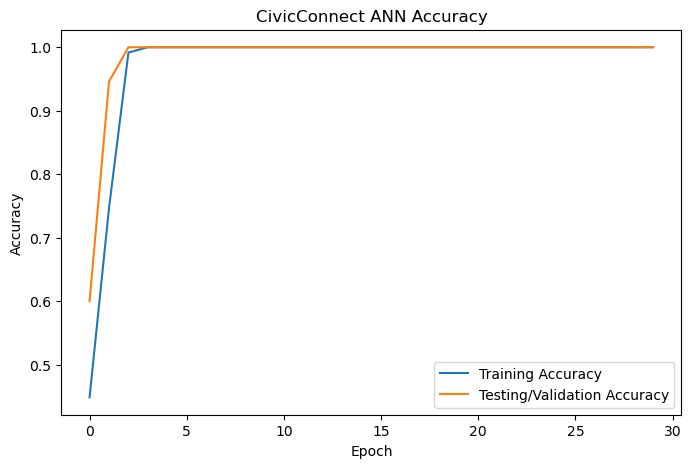

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Testing/Validation Accuracy")
plt.title("CivicConnect ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 28. Training and Validation Loss Plot

This graph shows how model loss changes during training.

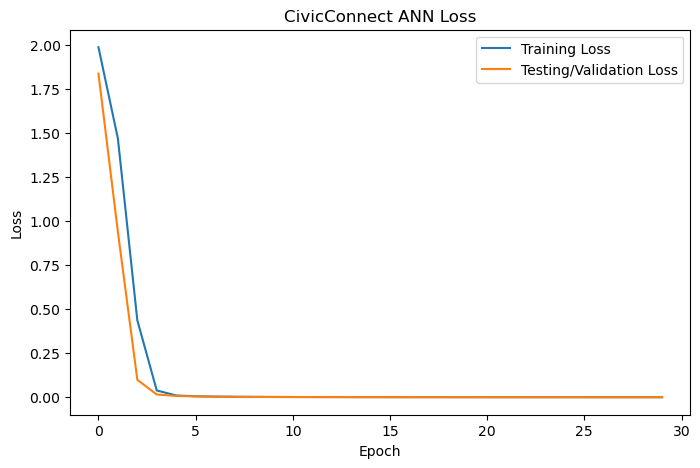

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Testing/Validation Loss")
plt.title("CivicConnect ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 29. Test Predictions

The trained ANN predicts the civic category for unseen test complaints.

In [29]:
y_prob = ann.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print("Actual labels:", y_test[:10])
print("Predicted labels:", y_pred[:10])

Actual labels: [1 5 0 0 1 3 1 6 5 1]
Predicted labels: [1 5 0 0 1 3 1 6 5 1]


## 30. Classification Metrics

Accuracy, precision, recall, and F1-score provide a detailed evaluation of the classifier.

In [30]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall * 100:.2f}%")
print(f"F1 Score : {f1 * 100:.2f}%")

Accuracy : 100.00%
Precision: 100.00%
Recall   : 100.00%
F1 Score : 100.00%


## 31. Classification Report

This report shows precision, recall, F1-score, and support for every civic category.

In [31]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

    Drainage       1.00      1.00      1.00        30
 Electricity       1.00      1.00      1.00        30
     Garbage       1.00      1.00      1.00        30
       Other       1.00      1.00      1.00        30
 Road Damage       1.00      1.00      1.00        30
  Sanitation       1.00      1.00      1.00        30
Street Light       1.00      1.00      1.00        30
Water Supply       1.00      1.00      1.00        30

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



## 32. Confusion Matrix

The confusion matrix shows correct and incorrect predictions for each CivicConnect category.

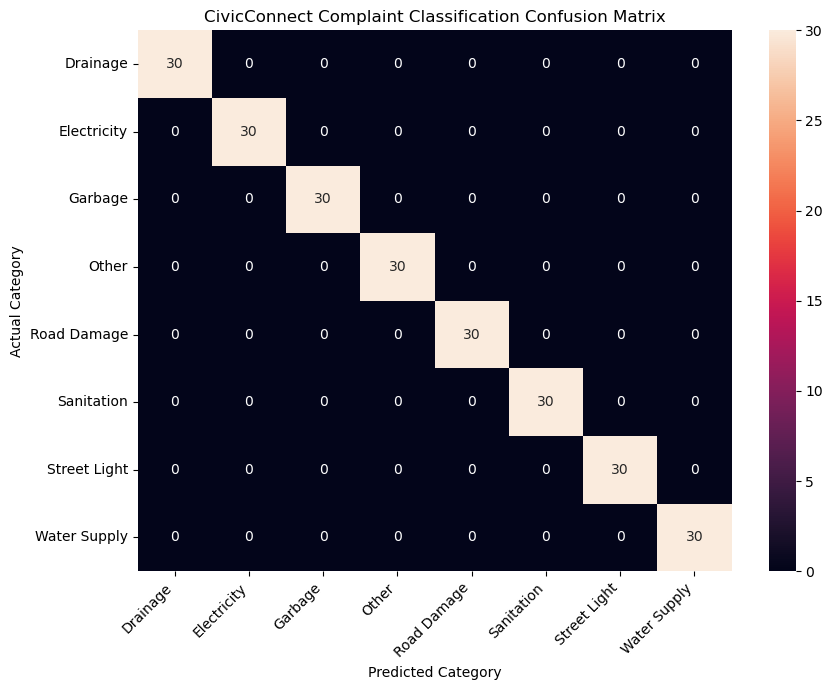

In [32]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("CivicConnect Complaint Classification Confusion Matrix")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 33. Actual vs Predicted Complaints

A few unseen complaints are displayed with their actual and predicted categories.

In [33]:
comparison = pd.DataFrame({
    "Complaint": X_test_text.reset_index(drop=True).head(15),
    "Actual Category": label_encoder.inverse_transform(y_test[:15]),
    "Predicted Category": label_encoder.inverse_transform(y_pred[:15])
})

comparison

,Complaint,Actual Category,Predicted Category
0,Power supply has stopped in our street,Electricity,Electricity
1,Cleaning workers are not visiting regularly,Sanitation,Sanitation
2,Sewage is overflowing on the street,Drainage,Drainage
3,The drainage system needs immediate repair,Drainage,Drainage
4,Power supply has stopped in our street,Electricity,Electricity
5,A public facility needs attention,Other,Other
6,Electricity is unavailable in the area,Electricity,Electricity
7,The lamp post light has stopped working,Street Light,Street Light
8,The public area is not being cleaned,Sanitation,Sanitation
9,Electricity is unavailable in the area,Electricity,Electricity


## 34. Correct and Incorrect Predictions

This cell counts how many test complaints were classified correctly.

In [34]:
correct = np.sum(y_test == y_pred)
incorrect = np.sum(y_test != y_pred)

print("Correct predictions:", correct)
print("Incorrect predictions:", incorrect)
print("Total testing complaints:", len(y_test))

Correct predictions: 240
Incorrect predictions: 0
Total testing complaints: 240


## 35. New Complaint Prediction

Enter a new citizen complaint and let CivicConnect AI predict its category.

In [35]:
new_complaint = [
    "There is a large pothole and damaged road near our village school."
]

new_features = tfidf.transform(new_complaint).toarray()
new_prediction = ann.predict(new_features, verbose=0)
predicted_index = np.argmax(new_prediction, axis=1)[0]
predicted_category = label_encoder.inverse_transform([predicted_index])[0]

print("Complaint:", new_complaint[0])
print("Predicted Civic Category:", predicted_category)

Complaint: There is a large pothole and damaged road near our village school.
Predicted Civic Category: Road Damage


## 36. Multiple New Complaint Predictions

Several example complaints are classified automatically by CivicConnect AI.

In [36]:
new_complaints = [
    "Garbage has not been collected for many days.",
    "Street light is not working near the main road.",
    "There is no proper drinking water supply in our area.",
    "The drainage is blocked and dirty water is overflowing."
]

new_features = tfidf.transform(new_complaints).toarray()
new_probs = ann.predict(new_features, verbose=0)
new_indices = np.argmax(new_probs, axis=1)
new_categories = label_encoder.inverse_transform(new_indices)

for complaint, category in zip(new_complaints, new_categories):
    print("Complaint:", complaint)
    print("Predicted Category:", category)
    print("-" * 60)

Complaint: Garbage has not been collected for many days.
Predicted Category: Garbage
------------------------------------------------------------
Complaint: Street light is not working near the main road.
Predicted Category: Street Light
------------------------------------------------------------
Complaint: There is no proper drinking water supply in our area.
Predicted Category: Water Supply
------------------------------------------------------------
Complaint: The drainage is blocked and dirty water is overflowing.
Predicted Category: Drainage
------------------------------------------------------------


## 37. Save the ANN Model

The trained CivicConnect ANN is saved so it can be reused without retraining.

In [37]:
ann.save("civicconnect_ann_model.keras")
print("ANN model saved successfully! ✅")

ANN model saved successfully! ✅


## 38. Save TF-IDF and Label Encoder

The feature transformer and category encoder are also saved for future predictions.

In [38]:
import joblib

joblib.dump(tfidf, "civicconnect_tfidf.pkl")
joblib.dump(label_encoder, "civicconnect_label_encoder.pkl")

print("TF-IDF and Label Encoder saved successfully! ✅")

TF-IDF and Label Encoder saved successfully! ✅


## 39. Load Saved Model

The saved model can be loaded again for deployment in the CivicConnect application.

In [39]:
loaded_ann = load_model("civicconnect_ann_model.keras")

loaded_tfidf = joblib.load("civicconnect_tfidf.pkl")
loaded_encoder = joblib.load("civicconnect_label_encoder.pkl")

print("Saved CivicConnect AI model loaded successfully! ✅")

Saved CivicConnect AI model loaded successfully! ✅


## 40. Final AI Workflow

**Citizen Complaint → Text Input → TF-IDF → ANN → Complaint Category → Department Routing → Resolution Tracking**

This AI component can support automatic classification inside the CivicConnect platform.

In [40]:
print("CivicConnect AI Workflow")
print("1. Citizen submits a complaint")
print("2. Complaint text is processed")
print("3. TF-IDF converts text into numerical features")
print("4. ANN predicts the civic complaint category")
print("5. Complaint can be routed to the responsible department")
print("6. Citizen can track the resolution")

CivicConnect AI Workflow
1. Citizen submits a complaint
2. Complaint text is processed
3. TF-IDF converts text into numerical features
4. ANN predicts the civic complaint category
5. Complaint can be routed to the responsible department
6. Citizen can track the resolution


# Conclusion

CivicConnect AI uses machine learning to automatically classify citizen complaints.
The notebook includes training, testing accuracy, evaluation metrics, confusion matrix, and new complaint prediction for a real-world civic grievance workflow.